In [227]:
#VaR basado en un portafolio de varias acciones
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yt
import matplotlib.pyplot as plt
from scipy.stats import norm
import random

In [228]:
#Traer datos de varias acciones
years = 15
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days=years*365)
print(f"Fecha de inicio: {startDate}, Fecha de fin: {endDate}")

Fecha de inicio: 2011-09-25 18:33:33.892804, Fecha de fin: 2026-09-21 18:33:33.892804


In [229]:
#lista tickets
tickets = ['SPY', 'BND', 'GLD', 'QQQ', 'VTI']


In [230]:
#Descargar
adj_close_df = pd.DataFrame()
for ticket in tickets:
    data = yt.download(ticket, start=startDate, end=endDate)
    adj_close_df[ticket] = data['Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [231]:
adj_close_df.head()

,SPY,BND,GLD,QQQ,VTI
Date,,,,,
2011-09-26,89.517456,54.310829,157.580002,48.200356,45.999027
2011-09-27,90.518631,54.200623,160.630005,48.701893,46.580132
2011-09-28,88.670357,54.083973,156.220001,47.980389,45.518654
2011-09-29,89.371155,54.077450,157.699997,47.408447,45.851830
2011-09-30,87.137863,54.278393,158.059998,46.185413,44.720646


In [232]:
#calcular retornos diarios
log_returns = np.log(adj_close_df/adj_close_df.shift(1))
log_returns = log_returns.dropna()
print(log_returns)

                 SPY       BND       GLD       QQQ       VTI
Date                                                        
2011-09-27  0.011122 -0.002031  0.019170  0.010351  0.012554
2011-09-28 -0.020630 -0.002155 -0.027838 -0.014926 -0.023052
2011-09-29  0.007872 -0.000121  0.009429 -0.011992  0.007293
2011-09-30 -0.025306  0.003709  0.002280 -0.026136 -0.024980
2011-10-03 -0.028871  0.005659  0.018181 -0.026056 -0.033651
...              ...       ...       ...       ...       ...
2026-09-14 -0.004472 -0.000702 -0.014982 -0.008005 -0.004341
2026-09-15 -0.004597 -0.000281  0.003329 -0.006564 -0.004923
2026-09-16 -0.004420 -0.000562 -0.006133  0.000255 -0.004247
2026-09-17  0.011275  0.005050  0.016758  0.017164  0.010930
2026-09-18  0.001286 -0.003785  0.007029  0.006299  0.000240

[3766 rows x 5 columns]


In [233]:
#desviacion 
def expected_return(weights, log_returns):
    return np.sum(log_returns.mean() * weights)

In [234]:
#desviacion estandar del portafolio
def standard_deviation(weights, cov_matrix):
    variance = weights.T @ cov_matrix @ weights
    return np.sqrt(variance)

In [235]:
#definir la covarianza de los retornos
cov_matrix = log_returns.cov()
print(cov_matrix)

          SPY       BND       GLD       QQQ       VTI
SPY  0.000112  0.000002  0.000010  0.000128  0.000114
BND  0.000002  0.000010  0.000009  0.000003  0.000003
GLD  0.000010  0.000009  0.000110  0.000013  0.000011
QQQ  0.000128  0.000003  0.000013  0.000169  0.000130
VTI  0.000114  0.000003  0.000011  0.000130  0.000116


In [236]:
#calcular la rentabilidad esperada y dv del portafolio
portfolio_value = 1000000
weights = np.array([1/len(tickets)]*len(tickets))
portfolio_expected_return = expected_return(weights, log_returns)
portfolio_std_dev = standard_deviation(weights, cov_matrix)



In [237]:
print(f"Expected Return: {portfolio_expected_return*100:.2f}%")
print(f"Standard Deviation: {portfolio_std_dev*100:.2f}%")

Expected Return: 0.04%
Standard Deviation: 0.74%


In [238]:
#deficion del metodo de montecarlo para simular el portafolio
def random_z_score():
    return np.random.normal(0, 1)

In [239]:
#CREAR SCENARIO DE PERDIDA O GANANCIA
days = 20
def scenario_gain_loss(portfolio_value, z_score, portfolio_std_dev, days):
    return (portfolio_value * portfolio_expected_return * days) + (portfolio_value * portfolio_std_dev * z_score * np.sqrt(days))

In [240]:
#SIMULACION DE MONTECARLO
simulations = 10000
scenario_returns = []

for i in range(simulations):
    z_score = random_z_score()
    scenario_returns.append(scenario_gain_loss(portfolio_value, z_score, portfolio_std_dev, days))

scenario_returns = np.array(scenario_returns)

In [241]:
#Calculo de VAR
confidence_interval = 0.95
var = -np.percentile(scenario_returns, (1-confidence_interval)*100)
print(f"Value at Risk (VaR) at {confidence_interval*100:.0f}% de confianza es: ${var:,.2f}")

Value at Risk (VaR) at 95% de confianza es: $45,725.99


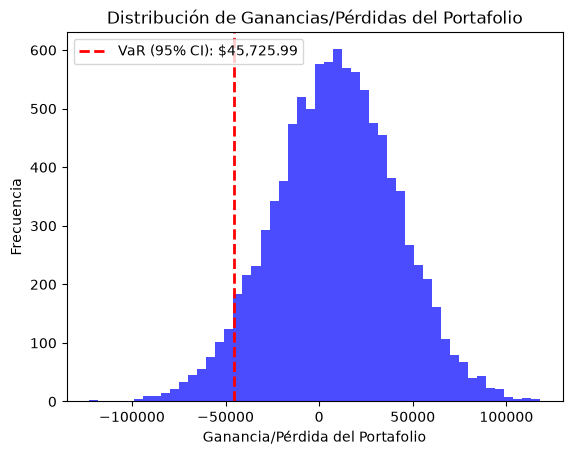

In [242]:
#Splot Visual var
plt.Figure(figsize=(10, 6))
plt.hist(scenario_returns, bins=50, alpha=0.7, color='blue')
plt.xlabel('Ganancia/Pérdida del Portafolio')
plt.ylabel('Frecuencia')
plt.title('Distribución de Ganancias/Pérdidas del Portafolio')
plt.axvline(-var, color='red', linestyle='dashed', linewidth=2, label=f'VaR (95% CI): ${var:,.2f}')
plt.legend()
plt.show()